INFORMASI DATASET
Jumlah data yang diolah : 120 data rumah
Jumlah fitur yang digunakan : 11 fitur

Fitur yang digunakan:
1. Bangunan Berdiri
2. Atap Bocor/Lepas
3. Rangka Atap Patah
4. Kolom/Balok Retak
5. Kolom/Balok Patah
6. Dinding Retak
7. Dinding Roboh
8. Lantai Rusak
9. Langit-langit Lepas
10. Instalasi Listrik Rusak
11. Pintu/Jendela Rusak

DISTRIBUSI LABEL ASLI
Rusak Sedang    : 79    data (65.8%)
Rusak Ringan    : 32    data (26.7%)
Rusak Berat     : 9     data (7.5%)

PEMBAGIAN DATA
Total data yang diolah : 120 data
Data training          : 96 data
Data testing           : 24 data

TABEL HASIL PREDIKSI DECISION TREE
 No  Kabupaten/Kota  Persentase Kerusakan   Label Asli Hasil Prediksi Decision Tree
  1   Pasaman Barat             21.212121 Rusak Ringan                 Rusak Ringan
  2            Agam             39.393939 Rusak Sedang                 Rusak Sedang
  3 Pesisir Selatan             30.303030 Rusak Sedang                 Rusak Sedang
  4   Solok Selatan           

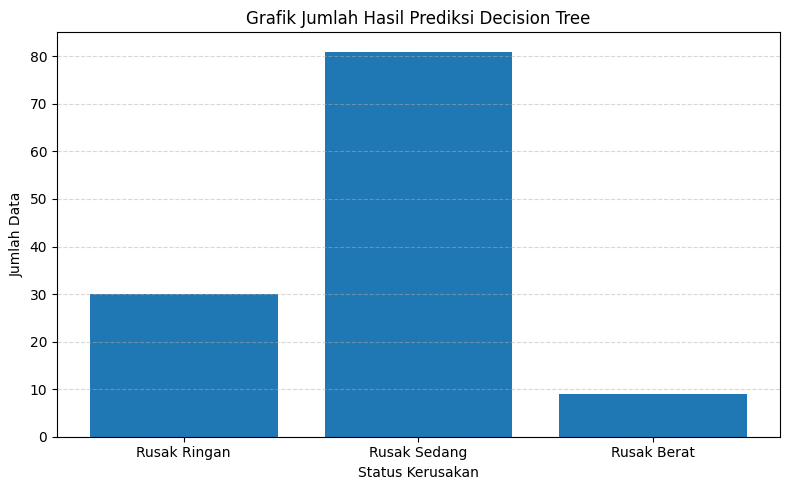

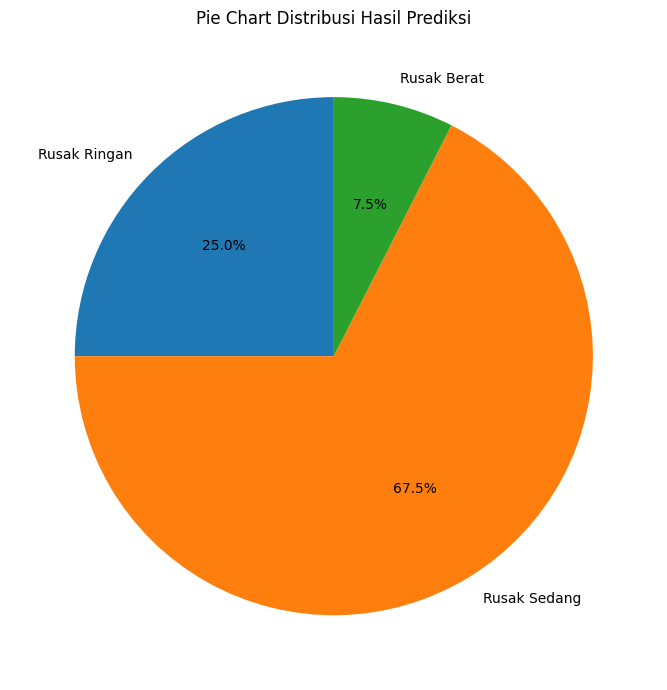

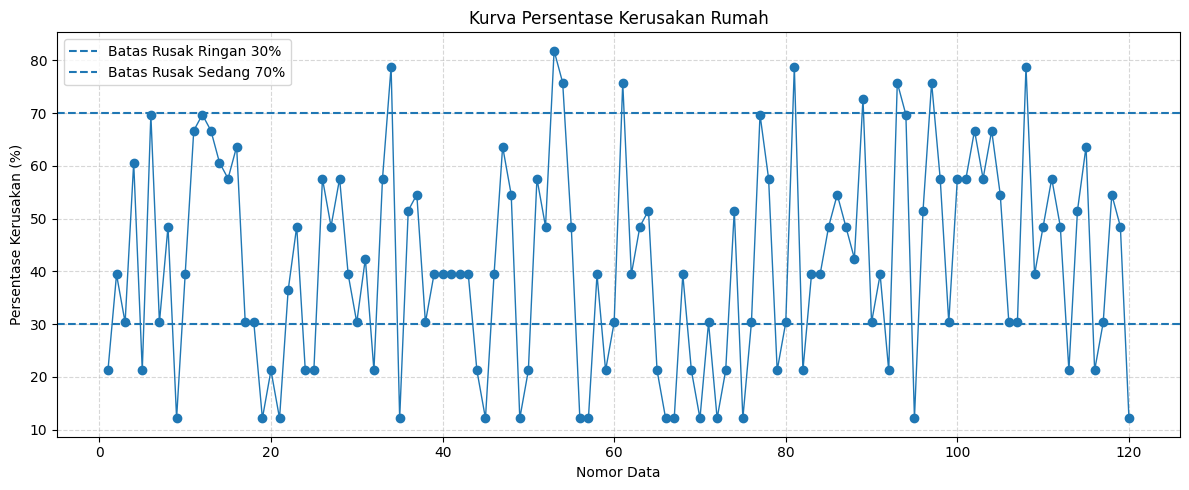

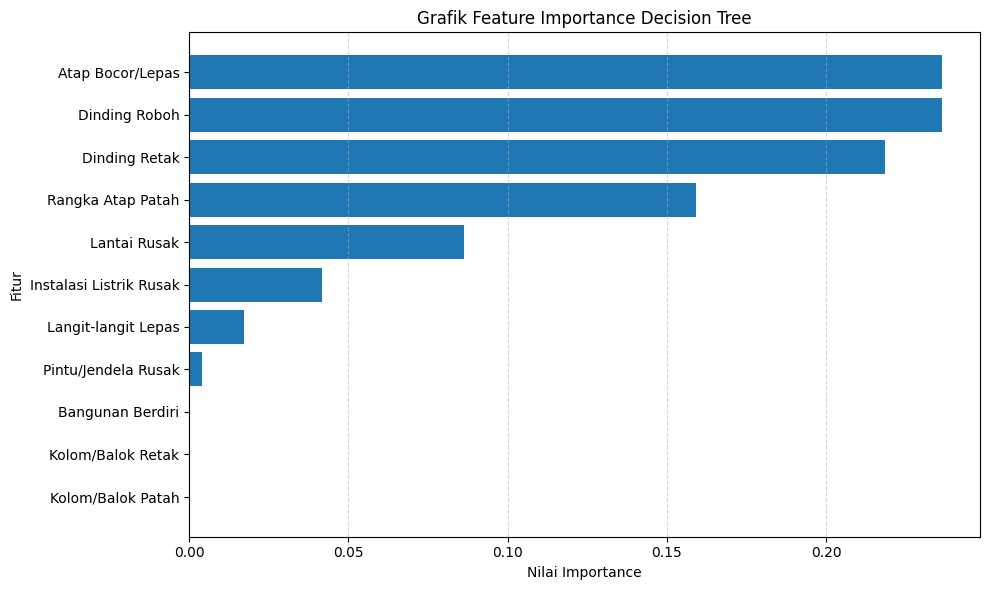

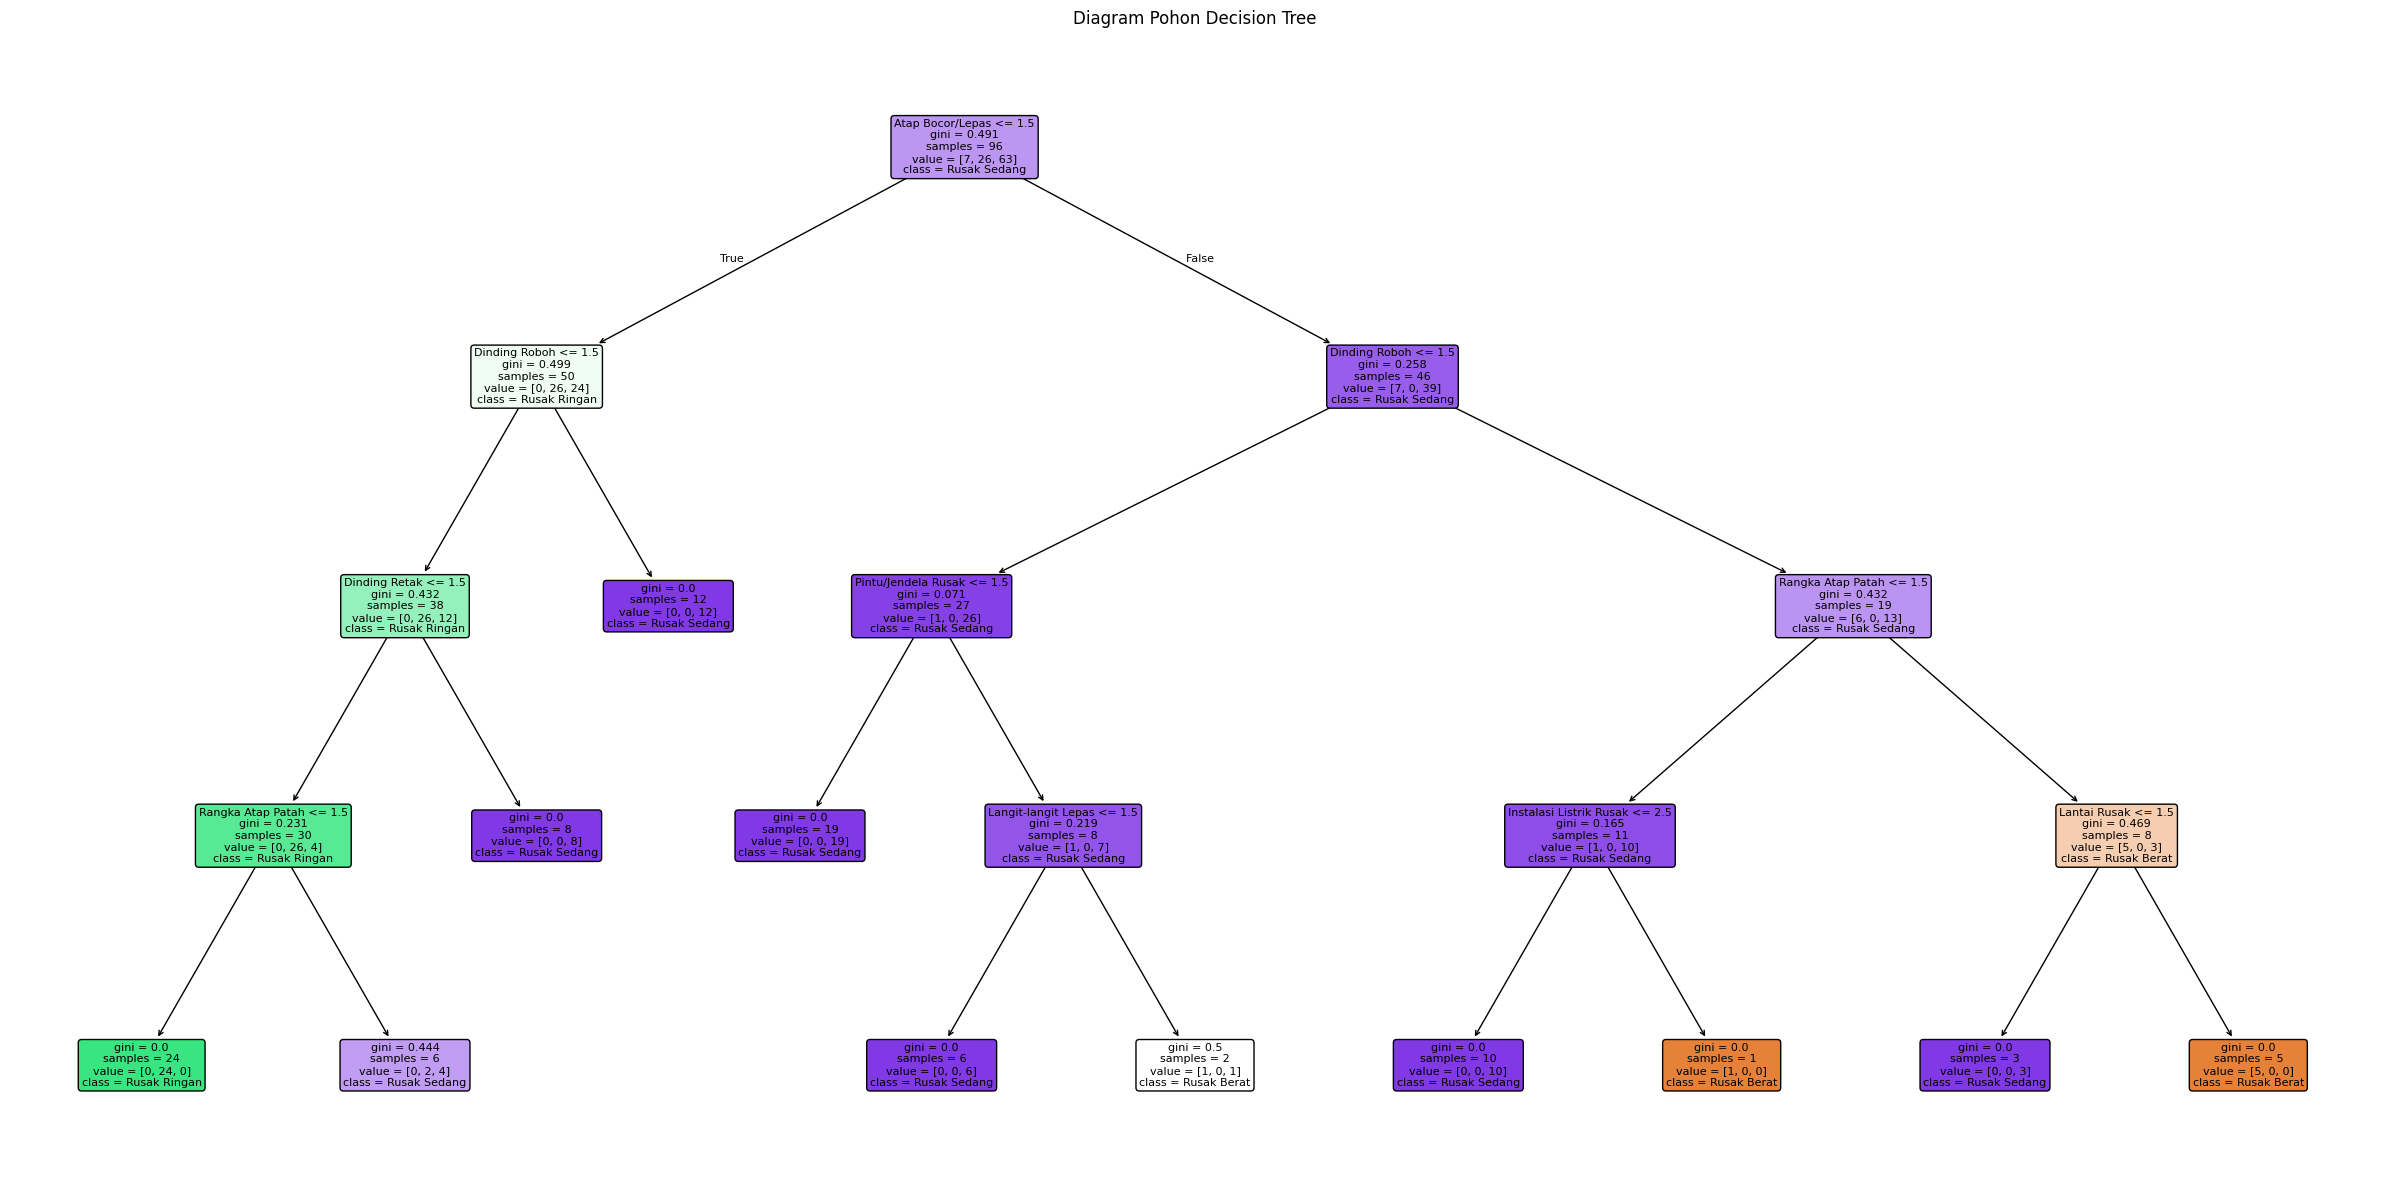


PROGRAM SELESAI
Jumlah data yang berhasil diolah : 120 data rumah
Jumlah data training             : 96 data
Jumlah data testing              : 24 data
Jumlah fitur                     : 11 fitur

File Excel berhasil disimpan dengan nama:
- hasil_decision_tree.xlsx

File gambar visualisasi berhasil dibuat:
- grafik_batang_prediksi.png
- pie_chart_prediksi.png
- kurva_persentase_kerusakan.png
- feature_importance_decision_tree.png
- diagram_pohon_decision_tree.png


In [1]:
# ============================================
# PROGRAM KLASIFIKASI KERUSAKAN RUMAH
# ALGORITMA DECISION TREE
# DENGAN OUTPUT TABEL, DIAGRAM, DAN KURVA
# ============================================

import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from openpyxl.drawing.image import Image as XLImage

warnings.filterwarnings('ignore')


# ========== 1. LOAD DATA ==========
df = pd.read_excel(
    'dataset_mentah_kerusakan_rumah_sumbar.xlsx',
    sheet_name='Dataset Mentah Rumah'
)

# Jika kolom No tidak ada, maka dibuat otomatis
if 'No' not in df.columns:
    df.insert(0, 'No', range(1, len(df) + 1))

# Jika kolom Kabupaten/Kota tidak ada, maka dibuat otomatis
if 'Kabupaten/Kota' not in df.columns:
    df['Kabupaten/Kota'] = '-'

print("=" * 80)
print("INFORMASI DATASET")
print("=" * 80)
print(f"Jumlah data yang diolah : {len(df)} data rumah")


# ========== 2. FITUR YANG DIGUNAKAN ==========
fitur = [
    'Bangunan Berdiri',
    'Atap Bocor/Lepas',
    'Rangka Atap Patah',
    'Kolom/Balok Retak',
    'Kolom/Balok Patah',
    'Dinding Retak',
    'Dinding Roboh',
    'Lantai Rusak',
    'Langit-langit Lepas',
    'Instalasi Listrik Rusak',
    'Pintu/Jendela Rusak'
]

print(f"Jumlah fitur yang digunakan : {len(fitur)} fitur")

print("\nFitur yang digunakan:")
for i, f in enumerate(fitur, start=1):
    print(f"{i}. {f}")


# ========== 3. KONVERSI DATA KE ANGKA ==========
def konversi_skor(val):
    if pd.isna(val):
        return 0
    
    val = str(val).strip().lower()
    
    if val in ['total', 'ya', '✓', 'v', 'roboh', 'runtuh', 'tidak berdiri']:
        return 3
    elif val in ['sebagian besar', 'sedang']:
        return 2
    elif val in ['sebagian', 'ringan', 'retak', 'bocor', 'lepas']:
        return 1
    else:
        return 0


for col in fitur:
    df[col] = df[col].apply(konversi_skor)


# ========== 4. MEMBUAT TOTAL SKOR DAN PERSENTASE ==========
df['total_skor'] = df[fitur].sum(axis=1)
df['persen'] = (df['total_skor'] / 33) * 100


# ========== 5. MENENTUKAN LABEL KERUSAKAN ==========
def tentukan_label(persen):
    if persen <= 30:
        return 'Rusak Ringan'
    elif persen <= 70:
        return 'Rusak Sedang'
    else:
        return 'Rusak Berat'


df['label_asli'] = df['persen'].apply(tentukan_label)

print("\n" + "=" * 80)
print("DISTRIBUSI LABEL ASLI")
print("=" * 80)

for label, jumlah in df['label_asli'].value_counts().items():
    persen_label = (jumlah / len(df)) * 100
    print(f"{label:<15} : {jumlah:<5} data ({persen_label:.1f}%)")


# ========== 6. MENYIAPKAN DATA TRAINING DAN TESTING ==========
X = df[fitur]
y = df['label_asli']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 80)
print("PEMBAGIAN DATA")
print("=" * 80)
print(f"Total data yang diolah : {len(df)} data")
print(f"Data training          : {len(X_train)} data")
print(f"Data testing           : {len(X_test)} data")


# ========== 7. FUNGSI HITUNG BANTUAN ==========
def hitung_bantuan(df, kolom_prediksi):
    bantuan = {
        'Rusak Ringan': 10000000,
        'Rusak Sedang': 25000000,
        'Rusak Berat': 50000000
    }
    
    total = df[kolom_prediksi].map(bantuan).sum()
    ringan = len(df[df[kolom_prediksi] == 'Rusak Ringan'])
    sedang = len(df[df[kolom_prediksi] == 'Rusak Sedang'])
    berat = len(df[df[kolom_prediksi] == 'Rusak Berat'])
    
    return total, ringan, sedang, berat


# ========== 8. LATIH MODEL DECISION TREE ==========
start = time.time()

dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt.fit(X_train, y_train)

df['Prediksi_Decision_Tree'] = dt.predict(X)

waktu_dt = time.time() - start
akurasi_dt = accuracy_score(y_test, dt.predict(X_test))

total_dt, r_dt, s_dt, b_dt = hitung_bantuan(df, 'Prediksi_Decision_Tree')


# ========== 9. TABEL HASIL SEMUA PREDIKSI ==========
print("\n" + "=" * 100)
print("TABEL HASIL PREDIKSI DECISION TREE")
print("=" * 100)

tabel_hasil = df[
    [
        'No',
        'Kabupaten/Kota',
        'persen',
        'label_asli',
        'Prediksi_Decision_Tree'
    ]
].copy()

tabel_hasil.columns = [
    'No',
    'Kabupaten/Kota',
    'Persentase Kerusakan',
    'Label Asli',
    'Hasil Prediksi Decision Tree'
]

print(tabel_hasil.to_string(index=False))


# ========== 10. JUMLAH HASIL PREDIKSI ==========
print("\n" + "=" * 80)
print("JUMLAH HASIL PREDIKSI DECISION TREE")
print("=" * 80)

print(f"Jumlah data yang diolah : {len(df)} data")
print(f"Akurasi Decision Tree   : {akurasi_dt:.2%}")
print(f"Waktu Proses            : {waktu_dt * 1000:.1f} ms")
print(f"Rusak Ringan            : {r_dt} data")
print(f"Rusak Sedang            : {s_dt} data")
print(f"Rusak Berat             : {b_dt} data")
print(f"Total Data              : {len(df)} data")
print(f"Total Bantuan           : Rp {total_dt:,.0f}")


# ========== 11. DISTRIBUSI PERSENTASE ==========
print("\n" + "=" * 80)
print("DISTRIBUSI PERSENTASE HASIL PREDIKSI")
print("=" * 80)

for status in ['Rusak Ringan', 'Rusak Sedang', 'Rusak Berat']:
    jumlah = len(df[df['Prediksi_Decision_Tree'] == status])
    persentase = (jumlah / len(df)) * 100
    print(f"{status:<15} : {jumlah:<5} data ({persentase:.1f}%)")


# ========== 12. ANALISA BERBASIS TABEL ==========
print("\n" + "=" * 80)
print("ANALISA BERBASIS TABEL")
print("=" * 80)

urutan_label = ['Rusak Ringan', 'Rusak Sedang', 'Rusak Berat']

bantuan_map = {
    'Rusak Ringan': 10000000,
    'Rusak Sedang': 25000000,
    'Rusak Berat': 50000000
}

jumlah_prediksi = df['Prediksi_Decision_Tree'].value_counts().reindex(urutan_label, fill_value=0)
persen_prediksi = (jumlah_prediksi / len(df)) * 100

tabel_analisa = pd.DataFrame({
    'Status Kerusakan': urutan_label,
    'Jumlah Data': jumlah_prediksi.values,
    'Persentase (%)': persen_prediksi.values.round(2),
    'Bantuan per Rumah': [bantuan_map[x] for x in urutan_label],
    'Total Bantuan': [jumlah_prediksi[x] * bantuan_map[x] for x in urutan_label]
})

print("\nTABEL ANALISA DISTRIBUSI PREDIKSI:")
print(tabel_analisa.to_string(index=False))


# ========== 13. CONFUSION MATRIX ==========
conf_matrix = pd.crosstab(
    df['label_asli'],
    df['Prediksi_Decision_Tree'],
    rownames=['Label Asli'],
    colnames=['Prediksi'],
    dropna=False
).reindex(index=urutan_label, columns=urutan_label, fill_value=0)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)
print(conf_matrix)


# ========== 14. LAPORAN KLASIFIKASI ==========
laporan_klasifikasi = pd.DataFrame(
    classification_report(
        y_test,
        dt.predict(X_test),
        output_dict=True,
        zero_division=0
    )
).transpose()

print("\n" + "=" * 80)
print("LAPORAN KLASIFIKASI DATA TESTING")
print("=" * 80)
print(laporan_klasifikasi)


# ========== 15. FEATURE IMPORTANCE ==========
fitur_importance = pd.DataFrame({
    'Fitur': fitur,
    'Nilai Importance': dt.feature_importances_
}).sort_values(by='Nilai Importance', ascending=False)

print("\n" + "=" * 80)
print("FITUR PALING BERPENGARUH")
print("=" * 80)
print(fitur_importance.to_string(index=False))


# ========== 16. GRAFIK BATANG HASIL PREDIKSI ==========
plt.figure(figsize=(8, 5))
plt.bar(tabel_analisa['Status Kerusakan'], tabel_analisa['Jumlah Data'])
plt.title('Grafik Jumlah Hasil Prediksi Decision Tree')
plt.xlabel('Status Kerusakan')
plt.ylabel('Jumlah Data')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('grafik_batang_prediksi.png', dpi=300)
plt.show()


# ========== 17. PIE CHART DISTRIBUSI PREDIKSI ==========
plt.figure(figsize=(7, 7))
plt.pie(
    tabel_analisa['Jumlah Data'],
    labels=tabel_analisa['Status Kerusakan'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Pie Chart Distribusi Hasil Prediksi')
plt.tight_layout()
plt.savefig('pie_chart_prediksi.png', dpi=300)
plt.show()


# ========== 18. KURVA PERSENTASE KERUSAKAN ==========
plt.figure(figsize=(12, 5))
plt.plot(
    range(1, len(df) + 1),
    df['persen'],
    marker='o',
    linewidth=1
)

plt.axhline(y=30, linestyle='--', label='Batas Rusak Ringan 30%')
plt.axhline(y=70, linestyle='--', label='Batas Rusak Sedang 70%')

plt.title('Kurva Persentase Kerusakan Rumah')
plt.xlabel('Nomor Data')
plt.ylabel('Persentase Kerusakan (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('kurva_persentase_kerusakan.png', dpi=300)
plt.show()


# ========== 19. GRAFIK FEATURE IMPORTANCE ==========
plt.figure(figsize=(10, 6))
plt.barh(
    fitur_importance['Fitur'],
    fitur_importance['Nilai Importance']
)

plt.title('Grafik Feature Importance Decision Tree')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('feature_importance_decision_tree.png', dpi=300)
plt.show()


# ========== 20. DIAGRAM POHON DECISION TREE ==========
plt.figure(figsize=(24, 12))

plot_tree(
    dt,
    feature_names=fitur,
    class_names=dt.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('Diagram Pohon Decision Tree')
plt.tight_layout()
plt.savefig('diagram_pohon_decision_tree.png', dpi=300)
plt.show()


# ========== 21. SIMPAN HASIL KE EXCEL ==========
with pd.ExcelWriter('hasil_decision_tree.xlsx', engine='openpyxl') as writer:
    
    tabel_hasil.to_excel(
        writer,
        sheet_name='Hasil_Prediksi',
        index=False
    )
    
    ringkasan = pd.DataFrame({
        'Keterangan': [
            'Jumlah Data yang Diolah',
            'Jumlah Fitur',
            'Data Training',
            'Data Testing',
            'Akurasi',
            'Waktu Proses',
            'Rusak Ringan',
            'Rusak Sedang',
            'Rusak Berat',
            'Total Data',
            'Total Bantuan'
        ],
        'Nilai': [
            len(df),
            len(fitur),
            len(X_train),
            len(X_test),
            f'{akurasi_dt:.2%}',
            f'{waktu_dt * 1000:.1f} ms',
            r_dt,
            s_dt,
            b_dt,
            len(df),
            f'Rp {total_dt:,.0f}'
        ]
    })
    
    ringkasan.to_excel(
        writer,
        sheet_name='Ringkasan',
        index=False
    )
    
    tabel_analisa.to_excel(
        writer,
        sheet_name='Tabel_Analisa',
        index=False
    )
    
    conf_matrix.to_excel(
        writer,
        sheet_name='Confusion_Matrix'
    )
    
    laporan_klasifikasi.to_excel(
        writer,
        sheet_name='Laporan_Klasifikasi'
    )
    
    fitur_importance.to_excel(
        writer,
        sheet_name='Feature_Importance',
        index=False
    )

    # Memasukkan gambar ke dalam Excel
    try:
        ws = writer.book.create_sheet('Visualisasi')

        daftar_gambar = [
            ('grafik_batang_prediksi.png', 'A1'),
            ('pie_chart_prediksi.png', 'A22'),
            ('kurva_persentase_kerusakan.png', 'A43'),
            ('feature_importance_decision_tree.png', 'A64'),
            ('diagram_pohon_decision_tree.png', 'A85')
        ]

        for nama_file, posisi in daftar_gambar:
            img = XLImage(nama_file)
            img.width = 700
            img.height = 400
            ws.add_image(img, posisi)

    except Exception as e:
        print(f"Gambar berhasil dibuat sebagai PNG, tetapi gagal dimasukkan ke Excel: {e}")


# ========== 22. OUTPUT AKHIR ==========
print("\n" + "=" * 80)
print("PROGRAM SELESAI")
print("=" * 80)

print(f"Jumlah data yang berhasil diolah : {len(df)} data rumah")
print(f"Jumlah data training             : {len(X_train)} data")
print(f"Jumlah data testing              : {len(X_test)} data")
print(f"Jumlah fitur                     : {len(fitur)} fitur")

print("\nFile Excel berhasil disimpan dengan nama:")
print("- hasil_decision_tree.xlsx")

print("\nFile gambar visualisasi berhasil dibuat:")
print("- grafik_batang_prediksi.png")
print("- pie_chart_prediksi.png")
print("- kurva_persentase_kerusakan.png")
print("- feature_importance_decision_tree.png")
print("- diagram_pohon_decision_tree.png")